**Split the Data**

 Tip: Keep ride_date out of your feature matrix — it identifies the row, it isn't a feature. Your trend column from C4 carries the time information instead.

In [49]:
import pandas as pandy
import numpy as numpy
import matplotlib.pyplot as mplot

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error


In [50]:
linre_df = pandy.read_csv('../Data/citibike_weather_daily_cleaned.csv')
linre_df.head(5)

,ride_date,num_rides,avg_duration_min,temp_f,max_temp_f,min_temp_f,wind_speed_knots,precip_in,month,Monday,Saturday,Sunday,Thursday,Tuesday,Wednesday,year
0,2013-07-01,16650,16.31,74.8,78.1,73.4,7.8,0.00,7,1,0,0,0,0,0,2013
1,2013-07-02,22745,15.97,76.1,82.9,73.0,8.0,0.73,7,0,0,0,0,1,0,2013
2,2013-07-03,21864,16.24,78.5,84.9,73.9,8.8,0.06,7,0,0,0,0,0,1,2013
3,2013-07-04,22326,21.22,82.0,91.0,73.9,8.6,0.96,7,0,0,0,1,0,0,2013
4,2013-07-05,21842,18.04,84.4,93.0,75.9,9.0,0.00,7,0,0,0,0,0,0,2013


In [51]:
# Defined the features and target variable
# Removed ride_date and whittled down the features to ones I'd like to model


y = linre_df['num_rides'] #Target
x = linre_df.drop(columns = ['num_rides', 'ride_date', 'max_temp_f', 'min_temp_f', 'avg_duration_min']) #Variables

y.shape, x.shape

((1610,), (1610, 11))

In [52]:
# Splitting the data into training and testing sets
# 80-20 split with a random state

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=50)

print('Training set:', x_train.shape, y_train.shape)
print('Testing set:', x_test.shape, y_test.shape)

Training set: (1288, 11) (1288,)
Testing set: (322, 11) (322,)


**Fit the Core Model**

In [53]:
model = LinearRegression()

model.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](11,)","[ 542.19, -250.94,-4017.85,..., 1389.44, 1879.01, 6287.53]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](11,)","['temp_f','wind_speed_knots','precip_in',...,'Tuesday','Wednesday','year']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-1.267e+07
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,11
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,11


In [54]:
# Set up predictions
# Predicted targets based on the features tested in model

y_train_pred = model.predict(x_train)
y_test_pred = model.predict(x_test)

**Evaluate**

Report R2, MAE and MSE scores

In [55]:
r2 = r2_score(y_test, y_test_pred)
mae = mean_absolute_error(y_test, y_test_pred)
mse = mean_squared_error(y_test, y_test_pred)

print(f"R2 Score: {r2:.4f}")
print(f"Mean Absolute Error: {mae:,.4f}")
print(f"Mean Squared Error: {mse:,.4f}")

R2 Score: 0.7398
Mean Absolute Error: 6,933.5261
Mean Squared Error: 74,816,547.2462


*Observations*

R2 score (0.7) measures the size of variance surrounding the target and it's features, or how well the model fits. The higher the number is (Or closer to 1?), the better the fit is. 0.74 would translate to approx 74%. In other words, the model fits about 74% well currently, and is about 30% off from accuracy. 

MAE (6,933.5) is the average absolute distance between predicted and actual feature values. A lower score is better here. This means the model is off by approx 6,900 num_rides. 

MSE (74,816,547.3) is the average distance squared between predicted and actual feature values. A lower score is better here. This is an abnormally large number I believe, probably due to my own errors in shaping and creating the models. This may be because the model as well does not account for missing holidays, or inclement and outlier bad weather events, like perhaps severe snow or thunderstorms, etc. 

**Interpret the Coefficients**

In [56]:
coefficients = pandy.DataFrame(model.coef_, x.columns, columns=['Coefficient'])

print("Coefficients sorted by absolute value:")
coefficients.sort_values(by='Coefficient', ascending=False).round(3)

Coefficients sorted by absolute value:


,Coefficient
year,6287.530
Wednesday,1879.013
Tuesday,1389.438
Thursday,1351.563
month,1022.543
temp_f,542.185
wind_speed_knots,-250.935
Monday,-1188.839
precip_in,-4017.855
Saturday,-5181.368


I personally was not able to gleam much information from the coefficients just sorting based on absolute value. Perhaps multicollinearity is an issue here, due to my own errors re: dummy variables, or redundancy in the dataset. The weekdays could be the source of possible high correlation here, skewing the model's accuracy.

I did a little research and discovered Permutation Importance as an alternative way to make sense of the model's scores and coefficients. Permutation Importance is more valuable in cases of linear regression for understanding what features are most significant to accurate predictions in the model. 

In [58]:
from sklearn.inspection import permutation_importance
# Compute permutation importance on the test set
# Researched an alt way to sort and interpret coefficients for better model prediction

perm_importance = permutation_importance(model, x_test, y_test, n_repeats = 30, random_state = 50, scoring = 'r2')

imp_df = pandy.DataFrame({'Feature': x.columns, 'Importance_Mean': perm_importance.importances_mean, 'Importance_STD': perm_importance.importances_std}).set_index('Feature')
imp_df = imp_df.sort_values('Importance_Mean', ascending=False).round(3)

print("Permutation Importance (Mean & STD):")
print(imp_df)

Permutation Importance (Mean & STD):
                  Importance_Mean  Importance_STD
Feature                                          
temp_f                      0.662           0.042
year                        0.644           0.059
month                       0.086           0.013
Sunday                      0.040           0.008
Saturday                    0.033           0.007
precip_in                   0.012           0.003
wind_speed_knots            0.007           0.003
Wednesday                   0.003           0.002
Thursday                    0.002           0.002
Monday                     -0.000           0.002
Tuesday                    -0.001           0.001


Temp_f (.66) and year (.64) are of the highest overall importance regarding prediction here. According to this model, temp and year are the most important features when it comes to predicting ridership (num_rides). At the bottom is most of the weekdays, meaning they have the least significance on predicting ridership under this current model. This is interesting because previously in Preprocessing, I discovered that Wednesdays were the highest day of ridership. But according to perm_imp, Weds are ranked lower in importance than Saturday and Sunday, which were the days with the lowest ridership throughout the week. 


**Diagnose With Residuals**

In [59]:
# imported ticker for better formatting of scatter plots

import matplotlib.ticker as mticker

residuals = y_test - y_test_pred
residuals.head()

965       62.461297
982    -1124.253074
107     9181.904052
382     -701.203242
1054   -8206.052736
Name: num_rides, dtype: float64

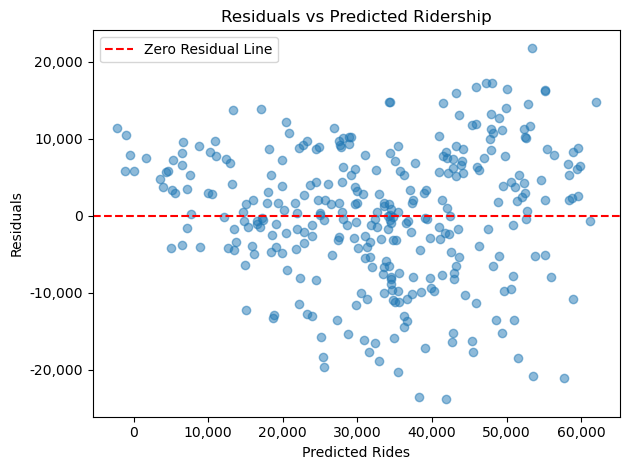

In [60]:
mplot.scatter(y_test_pred, residuals, alpha = 0.5)
mplot.axhline(y=0, color='red', linestyle='--', label='Zero Residual Line')
mplot.xlabel('Predicted Rides')
mplot.ylabel('Residuals')
mplot.title('Residuals vs Predicted Ridership')

ax = mplot.gca()
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, pos: '{:,.0f}'.format(x)))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, pos: '{:,.0f}'.format(x)))
mplot.legend()
mplot.tight_layout()

*Observations*

There is no sign of a curve or drift on this plot. There are clumps around the zero residual line, which I assume is good and well because that's in line with accuracy of the model. However, there is a slight outward fan shape across the scatterplot as predicted ridership grows. There are also many more outliers spread around in the higher predicted rides. This suggests that as ridership increases, the model is less accurate, and more errors are present. This reflects heteroscedasticity.

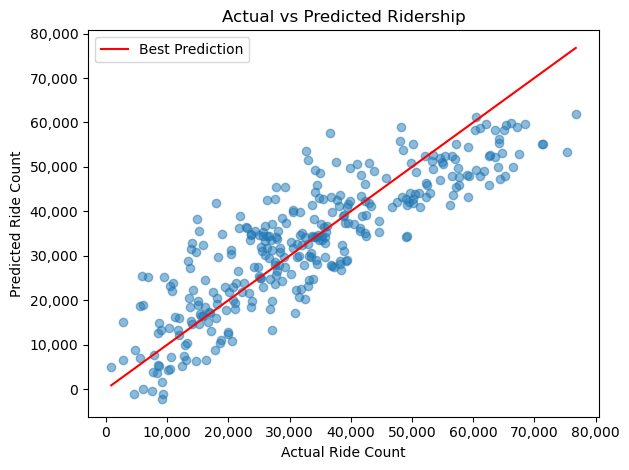

In [61]:
# Created scatter plots to visualize relationships in the data

mplot.scatter(y_test, y_test_pred, alpha = 0.5)
mplot.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color = 'red', label = 'Best Prediction')
mplot.xlabel('Actual Ride Count') 
mplot.ylabel('Predicted Ride Count')
mplot.title('Actual vs Predicted Ridership')

ax = mplot.gca()
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, pos: '{:,.0f}'.format(x)))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, pos: '{:,.0f}'.format(x)))
mplot.legend()
mplot.tight_layout()


*Observations*

This scatterplot shows a positive and strong relationship here. The points clumped together fairly tightly around the line of best predictions highlight the degree of accuracy of this model. The fit begins to drift below the red line at higher numbers of actual ridership, around 50-60k. This mirrors the previous scatterplots results as well, signifying that the model's prediction accuracy lessens as ridership increases. The model seems to be lacking some features that could help increase the accuracy rate, perhaps because of the missing data (IE: national holidays, inclement weather, etc) 

**Improve One Thing**

I want to refit the model and add a new feature variable, tracking observed national holidays. I believe the results will be different after this change!

In [62]:
# Install and include holidays 
# Pandas to change datetime format

import holidays

linre_df['ride_date'] = pandy.to_datetime(linre_df['ride_date'])
us_holidays = holidays.US(years=linre_df['ride_date'].dt.year.unique().tolist())

linre_df['is_holiday'] = linre_df['ride_date'].apply(lambda d: 1 if d in us_holidays else 0)

In [63]:
# Features and Target 2.0

y_improved = linre_df['num_rides'] 
x_improved = linre_df.drop(columns=['num_rides', 'ride_date', 'max_temp_f', 'min_temp_f', 'avg_duration_min'])

print(y_improved.shape, x_improved.shape)

(1610,) (1610, 12)


In [64]:
# Split the Data 2.0

x_train, x_test, y_train, y_test = train_test_split(x_improved, y_improved, test_size=0.2, random_state=50)

print('Training set:', x_train.shape, y_train.shape)
print('Testing set:', x_test.shape, y_test.shape)

# Training the Improved Model 2.0

model_improved = LinearRegression()
model_improved.fit(x_train, y_train)


Training set: (1288, 12) (1288,)
Testing set: (322, 12) (322,)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](12,)","[ 534.62, -257.89,-3734.47,..., 1829.13, 6301.7 ,-8835.62]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](12,)","['temp_f','wind_speed_knots','precip_in',...,'Wednesday','year', 'is_holiday']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-1.27e+07
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,12
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,12


In [65]:
# Predictions 2.0

y_train_pred = model_improved.predict(x_train)
y_test_pred = model_improved.predict(x_test)


In [66]:
# Evaluations 2.0

r2_improved = r2_score(y_test, y_test_pred)
mae_improved = mean_absolute_error(y_test, y_test_pred)
mse_improved = mean_squared_error(y_test, y_test_pred)

print("R2 Score (Improved):", r2_improved)
print("Mean Absolute Error (Improved):", mae_improved)
print("Mean Squared Error (Improved):", mse_improved)

R2 Score (Improved): 0.7461247400849862
Mean Absolute Error (Improved): 6809.6884599188
Mean Squared Error (Improved): 73001668.89215438


In [67]:
# Compared Main and Improved Models

print("Main & Improved Model Comparison:")
print(f"R2:  Main = {r2:.2f}  Improved = {r2_improved:.2f}")
print(f"MAE: Main = {mae:,.2f} Improved = {mae_improved:,.2f}")
print(f"MSE: Main = {mse:,.2f} Improved = {mse_improved:,.2f}")

Main & Improved Model Comparison:
R2:  Main = 0.74  Improved = 0.75
MAE: Main = 6,933.53 Improved = 6,809.69
MSE: Main = 74,816,547.25 Improved = 73,001,668.89


*Observations*

Adding a check to track holidays did slightly improve the model, but not in any significant way. There must be another way to address the additional missing dates/errors in fitting the model, but I will save those for another time.

**The Write Up**

See README.md for the summary.